In [1]:
# ============================================================
# Cell 1: FINAL NVT Configuration (40,000 Steps)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os, sys, json, time
from scipy.spatial import cKDTree
from tqdm.notebook import tqdm
from numba import njit, prange
from math import erfc, exp, sqrt, pi, log
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ===================== Physical Constants =====================
kB_eV = 8.617333262145e-5
NA = 6.02214076e23

# ===================== NVT Settings (40,000 Steps) =====================
TEMPERATURE_STAGES = [4000, 3000, 2000, 1500, 1000, 800, 600, 500, 400, 300, 300, 300, 300]
STEPS_PER_STAGE = 3000
TOTAL_STEPS = len(TEMPERATURE_STAGES) * STEPS_PER_STAGE

BOX_LENGTH = 31.98
TARGET_DENSITY = 2.2

CUTOFF = 12.0
COULOMB_CUTOFF = 12.0
WOLF_ALPHA = 0.2

SKIN = 0.8
NEIGHBOR_UPDATE_FREQ = 20

P_TARGET = 0.0
VOLUME_MOVE_PROB = 0.0  # NVT: no volume moves

TRAJ_OUTPUT_FREQ = 100

SEED = 42
rng = np.random.default_rng(SEED)

print("=" * 65)
print("🔬 NVT SIMULATION - 40,000 STEPS")
print("=" * 65)
print(f"Box: {BOX_LENGTH:.2f} Å | Target ρ: {TARGET_DENSITY} g/cm³")
print(f"Stages: {len(TEMPERATURE_STAGES)} | Steps/stage: {STEPS_PER_STAGE:,}")
print(f"Total steps: {TOTAL_STEPS:,}")
print(f"Cutoff: {CUTOFF} Å | Wolf α: {WOLF_ALPHA}")
print(f"Volume moves: DISABLED (NVT)")
print(f"Expected runtime: ~{TOTAL_STEPS * 0.05 / 60:.0f} min")
print("=" * 65)

🔬 NVT SIMULATION - 40,000 STEPS
Box: 31.98 Å | Target ρ: 2.2 g/cm³
Stages: 13 | Steps/stage: 3,000
Total steps: 39,000
Cutoff: 12.0 Å | Wolf α: 0.2
Volume moves: DISABLED (NVT)
Expected runtime: ~32 min


In [2]:
# ============================================================
# Cell 2: Parse Ternary.txt
# ============================================================
def parse_ternary_file(filename="Ternary.txt"):
    """
    Read structure file and extract atom types, coordinates.
    Automatically wraps coordinates into simulation box.
    """
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    n_atoms = int(lines[0].strip())
    data_lines = lines[2:2+n_atoms]
    
    atom_symbols = []
    coords_list = []
    
    for line in data_lines:
        parts = line.strip().split()
        if len(parts) >= 4:
            elem = parts[0]
            x, y, z = map(float, parts[1:4])
            atom_symbols.append(elem)
            coords_list.append([x, y, z])
    
    coords = np.array(coords_list, dtype=np.float64)
    
    # Wrap coordinates into box [0, BOX_LENGTH)
    coords = coords % BOX_LENGTH
    
    # Create type mapping
    unique_elements = sorted(set(atom_symbols))
    type_map = {el: i for i, el in enumerate(unique_elements)}
    type_indices = np.array([type_map[el] for el in atom_symbols], dtype=np.int32)
    
    print(f"Successfully parsed {len(atom_symbols)} atoms")
    print("Element composition:")
    for el in unique_elements:
        count = atom_symbols.count(el)
        print(f"  {el}: {count} atoms")
    print(f"Type mapping: {type_map}")
    print(f"Coordinate range: "
          f"[{coords[:,0].min():.2f}, {coords[:,0].max():.2f}] × "
          f"[{coords[:,1].min():.2f}, {coords[:,1].max():.2f}] × "
          f"[{coords[:,2].min():.2f}, {coords[:,2].max():.2f}]")
    
    return atom_symbols, coords, type_indices, type_map

# Execute parsing
atom_symbols, coords, type_indices, type_map = parse_ternary_file("Ternary.txt")
n_atoms = len(atom_symbols)

Successfully parsed 1960 atoms
Element composition:
  Ca: 252 atoms
  O: 1232 atoms
  P: 56 atoms
  Si: 420 atoms
Type mapping: {'Ca': 0, 'O': 1, 'P': 2, 'Si': 3}
Coordinate range: [0.46, 30.54] × [0.46, 30.54] × [0.46, 30.55]


In [3]:
# ============================================================
# Cell 3: Buckingham Parameters
# ============================================================
def load_buckingham_parameters(param_file=None):
    """
    Load Buckingham parameters.
    Uses literature values for SiO₂–CaO–P₂O₅ glass system.
    """
    if param_file and os.path.isfile(param_file):
        with open(param_file, 'r') as f:
            params_dict = json.load(f)
        return {tuple(k.split('-')): v for k, v in params_dict.items()}
    
    # Validated literature parameters
    default_params = {
        ('Si', 'O'): {'A': 1283.907,  'rho': 0.3205, 'C': 10.44},
        ('Ca', 'O'): {'A': 1272.7,    'rho': 0.2985, 'C': 0.0},
        ('P', 'O') : {'A': 900.0,     'rho': 0.33,   'C': 10.0},
        ('O', 'O') : {'A': 22764.0,   'rho': 0.149,  'C': 27.88}
    }
    return default_params

# Load parameters
buck_params = load_buckingham_parameters()

print("Buckingham parameters loaded:")
print(f"{'Pair':<12} {'A (eV)':<12} {'rho (Å)':<10} {'C (eV·Å⁶)':<12}")
print("-" * 46)
for (el1, el2), p in buck_params.items():
    print(f"{el1}-{el2:<9} {p['A']:<12.2f} {p['rho']:<10.4f} {p['C']:<12.2f}")

Buckingham parameters loaded:
Pair         A (eV)       rho (Å)    C (eV·Å⁶)   
----------------------------------------------
Si-O         1283.91      0.3205     10.44       
Ca-O         1272.70      0.2985     0.00        
P-O         900.00       0.3300     10.00       
O-O         22764.00     0.1490     27.88       


In [4]:
# ============================================================
# Cell 4: Charge Assignment
# ============================================================
# Partial charges ensuring overall neutrality
charge_dict = {
    'Si': 2.4,   # +2.4 e
    'Ca': 1.2,   # +1.2 e
    'P' : 3.0,   # +3.0 e
    'O' : -1.2   # -1.2 e
}

# Build charge array matching atom order
charges = np.array([charge_dict[sym] for sym in atom_symbols], dtype=np.float64)

# Verify neutrality
total_charge = np.sum(charges)

print("Charge assignment:")
for el, q in charge_dict.items():
    count = atom_symbols.count(el)
    if count > 0:
        print(f"  {el}: {q:+.1f} e × {count:4d} atoms = {q*count:+8.2f} e")
print(f"\nTotal system charge: {total_charge:.6f} e")

assert abs(total_charge) < 1e-6, "ERROR: System is not charge-neutral!"
print("✓ System is charge-neutral")

Charge assignment:
  Si: +2.4 e ×  420 atoms = +1008.00 e
  Ca: +1.2 e ×  252 atoms =  +302.40 e
  P: +3.0 e ×   56 atoms =  +168.00 e
  O: -1.2 e × 1232 atoms = -1478.40 e

Total system charge: 0.000000 e
✓ System is charge-neutral


In [5]:
# ============================================================
# Cell 5: Interaction Matrices & Verlet Neighbor List
# ============================================================
# --- Build type-indexed parameter matrices ---
num_types = len(type_map)
A_mat = np.zeros((num_types, num_types))
rho_mat = np.zeros((num_types, num_types))
C_mat = np.zeros((num_types, num_types))

for (el1, el2), params in buck_params.items():
    t1 = type_map[el1]
    t2 = type_map[el2]
    A_mat[t1, t2] = params['A']
    rho_mat[t1, t2] = params['rho']
    C_mat[t1, t2] = params['C']
    if t1 != t2:
        A_mat[t2, t1] = params['A']
        rho_mat[t2, t1] = params['rho']
        C_mat[t2, t1] = params['C']

print("Pairwise parameter matrices built:")
print(f"  Types: {type_map}")
print(f"  A matrix shape: {A_mat.shape}")

# --- Neighbor list functions ---
def build_neighbor_list(coords, box_size, cutoff, skin):
    """
    Build Verlet neighbor list using cKDTree with PBC.
    
    Returns
    -------
    pairs : ndarray (M, 2)
        Pairs of atom indices within cutoff + skin
    wrapped_coords : ndarray (N, 3)
        Coordinates wrapped into primary box
    """
    # Ensure boxsize is proper array
    if np.isscalar(box_size):
        boxsize = np.array([box_size, box_size, box_size], dtype=np.float64)
    else:
        boxsize = np.asarray(box_size, dtype=np.float64)
    
    box_L = boxsize[0]
    
    # Wrap coordinates
    wrapped_coords = coords % box_L
    
    # Build tree and query pairs
    tree = cKDTree(wrapped_coords, boxsize=boxsize)
    pairs = tree.query_pairs(cutoff + skin, output_type='ndarray')
    
    return pairs, wrapped_coords

def update_adjacency(pairs, n_atoms):
    """
    Convert pair list to adjacency list for fast local energy calculation.
    """
    adjacency = [set() for _ in range(n_atoms)]
    for i, j in pairs:
        adjacency[i].add(j)
        adjacency[j].add(i)
    # Convert to sorted arrays
    adjacency = [np.array(sorted(list(neighbors)), dtype=np.int32) 
                 for neighbors in adjacency]
    return adjacency

# Build initial neighbor list
neighbor_pairs, coords = build_neighbor_list(coords, BOX_LENGTH, CUTOFF, SKIN)
neighbor_adj = update_adjacency(neighbor_pairs, n_atoms)

# Statistics
n_pairs = neighbor_pairs.shape[0]
n_neighbors_per_atom = [len(adj) for adj in neighbor_adj]

print(f"\nInitial neighbor list:")
print(f"  Total pairs: {n_pairs}")
print(f"  Cutoff + skin: {CUTOFF + SKIN:.1f} Å")
print(f"  Neighbors per atom: min={min(n_neighbors_per_atom)}, "
      f"max={max(n_neighbors_per_atom)}, "
      f"mean={np.mean(n_neighbors_per_atom):.1f}")

Pairwise parameter matrices built:
  Types: {'Ca': 0, 'O': 1, 'P': 2, 'Si': 3}
  A matrix shape: (4, 4)

Initial neighbor list:
  Total pairs: 519934
  Cutoff + skin: 12.8 Å
  Neighbors per atom: min=438, max=640, mean=530.5


In [6]:
# ============================================================
# Cell 6: Total Energy Calculation (Buckingham + Wolf)
# ============================================================
@njit(parallel=False, fastmath=True)
def compute_total_energy(coords, charges, type_indices, A_mat, rho_mat, C_mat,
                         neighbor_pairs, box_size, cutoff, wolf_alpha):
    """
    Compute total pair energy: Buckingham + Wolf-shifted Coulomb.
    Uses minimum image convention for PBC.
    """
    n_pairs = neighbor_pairs.shape[0]
    energy = 0.0
    
    # Precompute Wolf shift constant
    wolf_shift = erfc(wolf_alpha * cutoff) / cutoff
    
    for p in range(n_pairs):
        i = neighbor_pairs[p, 0]
        j = neighbor_pairs[p, 1]
        
        # Displacement with minimum image convention
        dx = coords[i, 0] - coords[j, 0]
        dy = coords[i, 1] - coords[j, 1]
        dz = coords[i, 2] - coords[j, 2]
        
        dx = dx - box_size * round(dx / box_size)
        dy = dy - box_size * round(dy / box_size)
        dz = dz - box_size * round(dz / box_size)
        
        r = sqrt(dx*dx + dy*dy + dz*dz)
        
        # Skip if beyond cutoff or self-interaction
        if r >= cutoff or r < 1e-10:
            continue
        
        # Get interaction parameters
        ti = type_indices[i]
        tj = type_indices[j]
        A = A_mat[ti, tj]
        rho_val = rho_mat[ti, tj]
        C = C_mat[ti, tj]
        
        # Buckingham: A*exp(-r/rho) - C/r^6
        buck = 0.0
        if rho_val > 1e-10 and A > 0.0:
            buck = A * exp(-r / rho_val)
        if r > 1e-10:
            buck -= C / (r**6)
        
        # Wolf-shifted Coulomb
        qiqj = charges[i] * charges[j]
        coul = qiqj * (erfc(wolf_alpha * r) / r - wolf_shift)
        
        energy += buck + coul
    
    return energy

# Compute initial energy
print("Computing initial energy...")
U_pair = compute_total_energy(coords, charges, type_indices, 
                              A_mat, rho_mat, C_mat,
                              neighbor_pairs, BOX_LENGTH, CUTOFF, WOLF_ALPHA)

# Wolf self-energy correction
U_self = - (WOLF_ALPHA / sqrt(pi)) * np.sum(charges**2)
U_total = U_pair + U_self

print(f"\nEnergy breakdown:")
print(f"  Pair energy:        {U_pair:12.3f} eV")
print(f"  Wolf self-energy:   {U_self:12.3f} eV")
print(f"  Total energy:       {U_total:12.3f} eV")
print(f"  Energy per atom:    {U_total/n_atoms:12.4f} eV/atom")

# Verify no NaN/Inf
assert not np.isnan(U_total), "Energy is NaN!"
assert not np.isinf(U_total), "Energy is Inf!"
print("✓ Energy calculation valid")

Computing initial energy...

Energy breakdown:
  Pair energy:           12748.598 eV
  Wolf self-energy:       -570.978 eV
  Total energy:          12177.620 eV
  Energy per atom:          6.2131 eV/atom
✓ Energy calculation valid


In [7]:
# ============================================================
# Cell 7: Local Atom Energy (for efficient displacement moves)
# ============================================================
@njit(fastmath=True)
def compute_atom_local_energy(atom_idx, coords, charges, type_indices,
                              A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
                              neighbor_list):
    """
    Compute energy contribution of a single atom with its neighbors.
    Returns U_i = 0.5 * Σ_j U_ij (half to avoid double counting).
    """
    energy = 0.0
    wolf_shift = erfc(wolf_alpha * cutoff) / cutoff
    n_neigh = len(neighbor_list[atom_idx])
    
    for k in range(n_neigh):
        j = neighbor_list[atom_idx][k]
        
        # Skip self
        if j == atom_idx:
            continue
        
        # Displacement with PBC
        dx = coords[atom_idx, 0] - coords[j, 0]
        dy = coords[atom_idx, 1] - coords[j, 1]
        dz = coords[atom_idx, 2] - coords[j, 2]
        
        dx = dx - box_size * round(dx / box_size)
        dy = dy - box_size * round(dy / box_size)
        dz = dz - box_size * round(dz / box_size)
        
        r = sqrt(dx*dx + dy*dy + dz*dz)
        
        if r < 1e-10 or r >= cutoff:
            continue
        
        ti = type_indices[atom_idx]
        tj = type_indices[j]
        A = A_mat[ti, tj]
        rho_val = rho_mat[ti, tj]
        C = C_mat[ti, tj]
        
        # Buckingham
        buck = 0.0
        if rho_val > 1e-10 and A > 0.0:
            buck = A * exp(-r / rho_val)
        if r > 1e-10:
            buck -= C / (r**6)
        
        # Coulomb
        qiqj = charges[atom_idx] * charges[j]
        coul = qiqj * (erfc(wolf_alpha * r) / r - wolf_shift)
        
        energy += buck + coul
    
    return energy * 0.5

# Validation: sum of local energies should equal U_pair
print("Validating local energy calculation...")
local_energies = np.array([
    compute_atom_local_energy(i, coords, charges, type_indices,
                              A_mat, rho_mat, C_mat, 
                              BOX_LENGTH, CUTOFF, WOLF_ALPHA,
                              neighbor_adj) 
    for i in range(n_atoms)
])

sum_local = np.sum(local_energies)
diff = abs(sum_local - U_pair)

print(f"  Sum of local energies: {sum_local:.3f} eV")
print(f"  Full pair energy:      {U_pair:.3f} eV")
print(f"  Difference:            {diff:.2e} eV")

if diff < 1e-6:
    print("✓ Local energy calculation validated")
else:
    print(f"⚠ Difference is {diff:.2e} eV (acceptable)")

Validating local energy calculation...
  Sum of local energies: 12748.598 eV
  Full pair energy:      12748.598 eV
  Difference:            1.26e-09 eV
✓ Local energy calculation validated


In [8]:
# ============================================================
# Cell 8: Atom Displacement Move (Metropolis)
# ============================================================
def attempt_displacement(coords, charges, type_indices, neighbor_adj,
                         A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
                         max_disp, temperature, energy_pair):
    """
    Attempt single-atom displacement with Metropolis acceptance.
    Uses local energy evaluation for efficiency.
    
    Returns
    -------
    coords : updated coordinates
    energy_pair : updated pair energy
    accepted : bool
    """
    n_atoms = coords.shape[0]
    
    # Pick random atom
    i = rng.integers(0, n_atoms)
    old_pos = coords[i].copy()
    
    # Propose random displacement
    delta = rng.uniform(-max_disp, max_disp, size=3)
    new_pos = old_pos + delta
    # Note: coordinates can go outside box; PBC handled in distance calculation
    
    # Compute old local energy
    old_local = compute_atom_local_energy(
        i, coords, charges, type_indices,
        A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
        neighbor_adj
    )
    
    # Apply displacement and compute new local energy
    coords[i] = new_pos
    new_local = compute_atom_local_energy(
        i, coords, charges, type_indices,
        A_mat, rho_mat, C_mat, box_size, cutoff, wolf_alpha,
        neighbor_adj
    )
    
    delta_e = new_local - old_local
    
    # Metropolis criterion
    accepted = False
    if delta_e <= 0.0:
        accepted = True
    else:
        beta = 1.0 / (kB_eV * temperature)
        if rng.random() < exp(-beta * delta_e):
            accepted = True
        else:
            # Reject: restore old position
            coords[i] = old_pos
    
    if accepted:
        energy_pair += delta_e
    
    return coords, energy_pair, accepted

print("✓ Displacement move function ready")

✓ Displacement move function ready


In [9]:
# ============================================================
# Cell 9: Volume Move for NPT (CORRECTED - No Pressure)
# ============================================================
def attempt_volume_move(coords, charges, type_indices,
                        A_mat, rho_mat, C_mat,
                        neighbor_pairs, neighbor_adj,
                        box_length, cutoff, wolf_alpha, skin,
                        vol_scale, temperature, energy_pair):
    """
    Attempt isotropic volume change.
    CORRECTED: No pressure term (P=0), pure NVT-like volume fluctuations.
    Acceptance: min[1, exp(-β(ΔU - NkT ln(V_new/V_old)))]
    """
    n_atoms = coords.shape[0]
    old_box = box_length
    
    # Propose small volume change
    delta_vol = vol_scale * (2.0 * rng.random() - 1.0)
    new_box = old_box * (1.0 + delta_vol)
    
    # Limit volume changes more strictly
    if new_box <= 0 or new_box > old_box * 1.5 or new_box < old_box * 0.5:
        return coords, box_length, neighbor_pairs, neighbor_adj, energy_pair, False
    
    scale_factor = new_box / old_box
    new_coords = coords * scale_factor
    
    # Build neighbor list for new configuration
    temp_pairs, temp_wrapped = build_neighbor_list(new_coords, new_box, cutoff, skin)
    temp_adj = update_adjacency(temp_pairs, n_atoms)
    
    # Compute new energy
    U_new_pair = compute_total_energy(
        temp_wrapped, charges, type_indices,
        A_mat, rho_mat, C_mat,
        temp_pairs, new_box, cutoff, wolf_alpha
    )
    
    # Energy change (self-energy is constant)
    U_old = energy_pair + U_self
    U_new = U_new_pair + U_self
    delta_U = U_new - U_old
    
    # NPT acceptance (P=0)
    vol_old = old_box ** 3
    vol_new = new_box ** 3
    w = delta_U - n_atoms * kB_eV * temperature * log(vol_new / vol_old)
    
    accepted = False
    if w <= 0:
        accepted = True
    else:
        beta = 1.0 / (kB_eV * temperature)
        if rng.random() < exp(-beta * w):
            accepted = True
    
    if accepted:
        return temp_wrapped, new_box, temp_pairs, temp_adj, U_new_pair, True
    else:
        return coords, box_length, neighbor_pairs, neighbor_adj, energy_pair, False

print("✓ Volume move function ready (corrected, no pressure)")

✓ Volume move function ready (corrected, no pressure)


In [10]:
# ============================================================
# Cell 10: NVT Annealing Loop (40,000 Steps)
# ============================================================
print("=" * 65)
print("🔬 NVT ANNEALING - 40,000 STEPS")
print("=" * 65)
print(f"Stages: {len(TEMPERATURE_STAGES)} | Total steps: {TOTAL_STEPS:,}")
print(f"Extra 300K equilibration: {sum(1 for t in TEMPERATURE_STAGES if t == 300)} stages")
print("=" * 65)

# --- Initialize ---
energy_log = np.zeros(TOTAL_STEPS)
accepted_displ = 0
attempts_displ = 0

traj_file = open("trajectory_nvt_40k.xyz", "w", encoding="utf-8")

current_box = BOX_LENGTH
current_energy_pair = U_pair
current_coords = coords.copy()
current_neighbor_pairs = neighbor_pairs.copy()
current_neighbor_adj = [adj.copy() for adj in neighbor_adj]

step_counter = 0
neighbor_update_counter = 0
energy_history = []

start_time = time.time()

for stage, T in enumerate(TEMPERATURE_STAGES):
    
    # --- Adaptive displacement ---
    if T >= 3000:
        max_disp = 0.15
    elif T >= 2000:
        max_disp = 0.12
    elif T >= 1000:
        max_disp = 0.08
    elif T >= 500:
        max_disp = 0.06
    elif T >= 400:
        max_disp = 0.05
    else:
        max_disp = 0.03
    
    stage_acc_d = 0
    stage_att_d = 0
    
    print(f"\nStage {stage+1}/{len(TEMPERATURE_STAGES)}: T = {T:4d}K | max_disp = {max_disp:.3f} A")
    
    pbar = tqdm(range(STEPS_PER_STAGE), desc=f"T={T:4d}K")
    
    for s in pbar:
        stage_att_d += 1
        attempts_displ += 1
        
        current_coords, current_energy_pair, accepted = attempt_displacement(
            current_coords, charges, type_indices,
            current_neighbor_adj,
            A_mat, rho_mat, C_mat,
            current_box, CUTOFF, WOLF_ALPHA,
            max_disp, T, current_energy_pair
        )
        
        if accepted:
            accepted_displ += 1
            stage_acc_d += 1
        
        if (step_counter + 1) % NEIGHBOR_UPDATE_FREQ == 0:
            current_neighbor_pairs, _ = build_neighbor_list(
                current_coords, current_box, CUTOFF, SKIN
            )
            current_neighbor_adj = update_adjacency(
                current_neighbor_pairs, n_atoms
            )
            neighbor_update_counter += 1
        
        energy_log[step_counter] = current_energy_pair + U_self
        
        if (step_counter + 1) % TRAJ_OUTPUT_FREQ == 0:
            traj_file.write(f"{n_atoms}\n")
            traj_file.write(f"Step {step_counter+1}, T={T}K\n")
            for sym, pos in zip(atom_symbols, current_coords):
                traj_file.write(f"{sym:2s} {pos[0]:10.6f} {pos[1]:10.6f} {pos[2]:10.6f}\n")
        
        if (step_counter + 1) % 1000 == 0:
            pbar.set_postfix({
                'E': f'{energy_log[step_counter]:.0f}',
                'Acc': f'{stage_acc_d/max(1,stage_att_d)*100:.0f}%'
            })
        
        step_counter += 1
    
    # --- Stage summary ---
    d_rate = stage_acc_d / max(1, stage_att_d) * 100
    stage_start = stage * STEPS_PER_STAGE
    stage_end = (stage + 1) * STEPS_PER_STAGE
    avg_E = np.mean(energy_log[stage_start:stage_end])
    std_E = np.std(energy_log[stage_start:stage_end])
    
    energy_history.append(avg_E)
    
    # Check equilibration at 300K
    if T == 300 and len(energy_history) >= 3:
        drift = abs(energy_history[-1] - energy_history[-2]) / abs(energy_history[-2]) * 100
        print(f"  Avg E: {avg_E:8.1f} ± {std_E:.1f} eV | Acc: {d_rate:5.1f}% | Drift: {drift:.4f}%")
        if drift < 0.01:
            print(f"  ✅ Equilibrated!")
    else:
        print(f"  Avg E: {avg_E:8.1f} ± {std_E:.1f} eV | Acc: {d_rate:5.1f}%")

traj_file.close()
elapsed_time = time.time() - start_time

# Update globals
coords = current_coords
box_length = current_box
U_pair = current_energy_pair
neighbor_pairs = current_neighbor_pairs
neighbor_adj = current_neighbor_adj

# Final report
total_d_rate = accepted_displ / max(1, attempts_displ) * 100
final_vol = current_box ** 3

molar_mass = {'Si': 28.0855, 'Ca': 40.078, 'P': 30.9738, 'O': 15.999}
total_mass_amu = sum(atom_symbols.count(el) * molar_mass[el] for el in molar_mass)
final_density_gcm3 = (total_mass_amu / NA) / (final_vol * 1e-24)
density_error = abs(final_density_gcm3 - TARGET_DENSITY) / TARGET_DENSITY * 100

print("\n" + "=" * 65)
print("✅ NVT SIMULATION COMPLETE (40,000 Steps)")
print("=" * 65)
print(f"Wall time: {elapsed_time:.1f}s ({elapsed_time/60:.1f} min)")
print(f"Time per step: {elapsed_time/TOTAL_STEPS*1000:.2f} ms")
print(f"Acceptance: {accepted_displ:,}/{attempts_displ:,} = {total_d_rate:.1f}%")
print(f"Neighbor updates: {neighbor_update_counter:,}")
print(f"\nFinal Configuration:")
print(f"  Box: {current_box:.4f} A (fixed)")
print(f"  Volume: {final_vol:,.1f} A³")
print(f"  Density: {final_density_gcm3:.4f} g/cm³ (target: {TARGET_DENSITY}, error: {density_error:.3f}%)")
print(f"  Energy: {energy_log[-1]:,.1f} eV ({energy_log[-1]/n_atoms:.4f} eV/atom)")
print(f"  Energy σ (last 3000 steps): {np.std(energy_log[-3000:]):.2f} eV")

with open("final_structure_nvt_40k.xyz", "w", encoding="utf-8") as f:
    f.write(f"{n_atoms}\n")
    f.write(f"NVT: {TOTAL_STEPS:,} steps, T=300K, Box={current_box:.4f}A, ρ={final_density_gcm3:.4f}g/cm³\n")
    for sym, pos in zip(atom_symbols, current_coords):
        f.write(f"{sym:2s} {pos[0]:10.6f} {pos[1]:10.6f} {pos[2]:10.6f}\n")

print("\n✓ final_structure_nvt_40k.xyz")
print("✓ trajectory_nvt_40k.xyz")

🔬 NVT ANNEALING - 40,000 STEPS
Stages: 13 | Total steps: 39,000
Extra 300K equilibration: 4 stages

Stage 1/13: T = 4000K | max_disp = 0.150 A


T=4000K:   0%|          | 0/3000 [00:00<?, ?it/s]

  Avg E:  11951.8 ± 133.1 eV | Acc:  63.8%

Stage 2/13: T = 3000K | max_disp = 0.150 A


T=3000K:   0%|          | 0/3000 [00:00<?, ?it/s]

  Avg E:  11457.1 ± 143.9 eV | Acc:  61.1%

Stage 3/13: T = 2000K | max_disp = 0.120 A


...

  Avg E:   9396.3 ± 24.9 eV | Acc:  62.7% | Drift: 0.9178%

Stage 12/13: T =  300K | max_disp = 0.030 A


T= 300K:   0%|          | 0/3000 [00:00<?, ?it/s]

  Avg E:   9305.9 ± 25.8 eV | Acc:  62.9% | Drift: 0.9628%

Stage 13/13: T =  300K | max_disp = 0.030 A


T= 300K:   0%|          | 0/3000 [00:00<?, ?it/s]

  Avg E:   9219.8 ± 25.1 eV | Acc:  62.4% | Drift: 0.9247%

✅ NVT SIMULATION COMPLETE (40,000 Steps)
Wall time: 1502.2s (25.0 min)
Time per step: 38.52 ms
Acceptance: 24,058/39,000 = 61.7%
Neighbor updates: 1,950

Final Configuration:
  Box: 31.9800 A (fixed)
  Volume: 32,706.6 A³
  Density: 2.2004 g/cm³ (target: 2.2, error: 0.020%)
  Energy: 9,175.7 eV (4.6815 eV/atom)
  Energy σ (last 3000 steps): 25.09 eV

✓ final_structure_nvt_40k.xyz
✓ trajectory_nvt_40k.xyz


ADVANCED SIMULATION RDF & CN ANALYSIS
Pair       CN       Cutoff     Peak r (A)   g(r) max  
------------------------------------------------------------
Si-O       3.71     2.4        1.77         8.46      
Ca-O       5.25     3.0        2.23         3.29      
P-O       3.79     2.4        1.73         8.62      
O-O       3.54     3.5        2.98         1.09      
------------------------------------------------------------


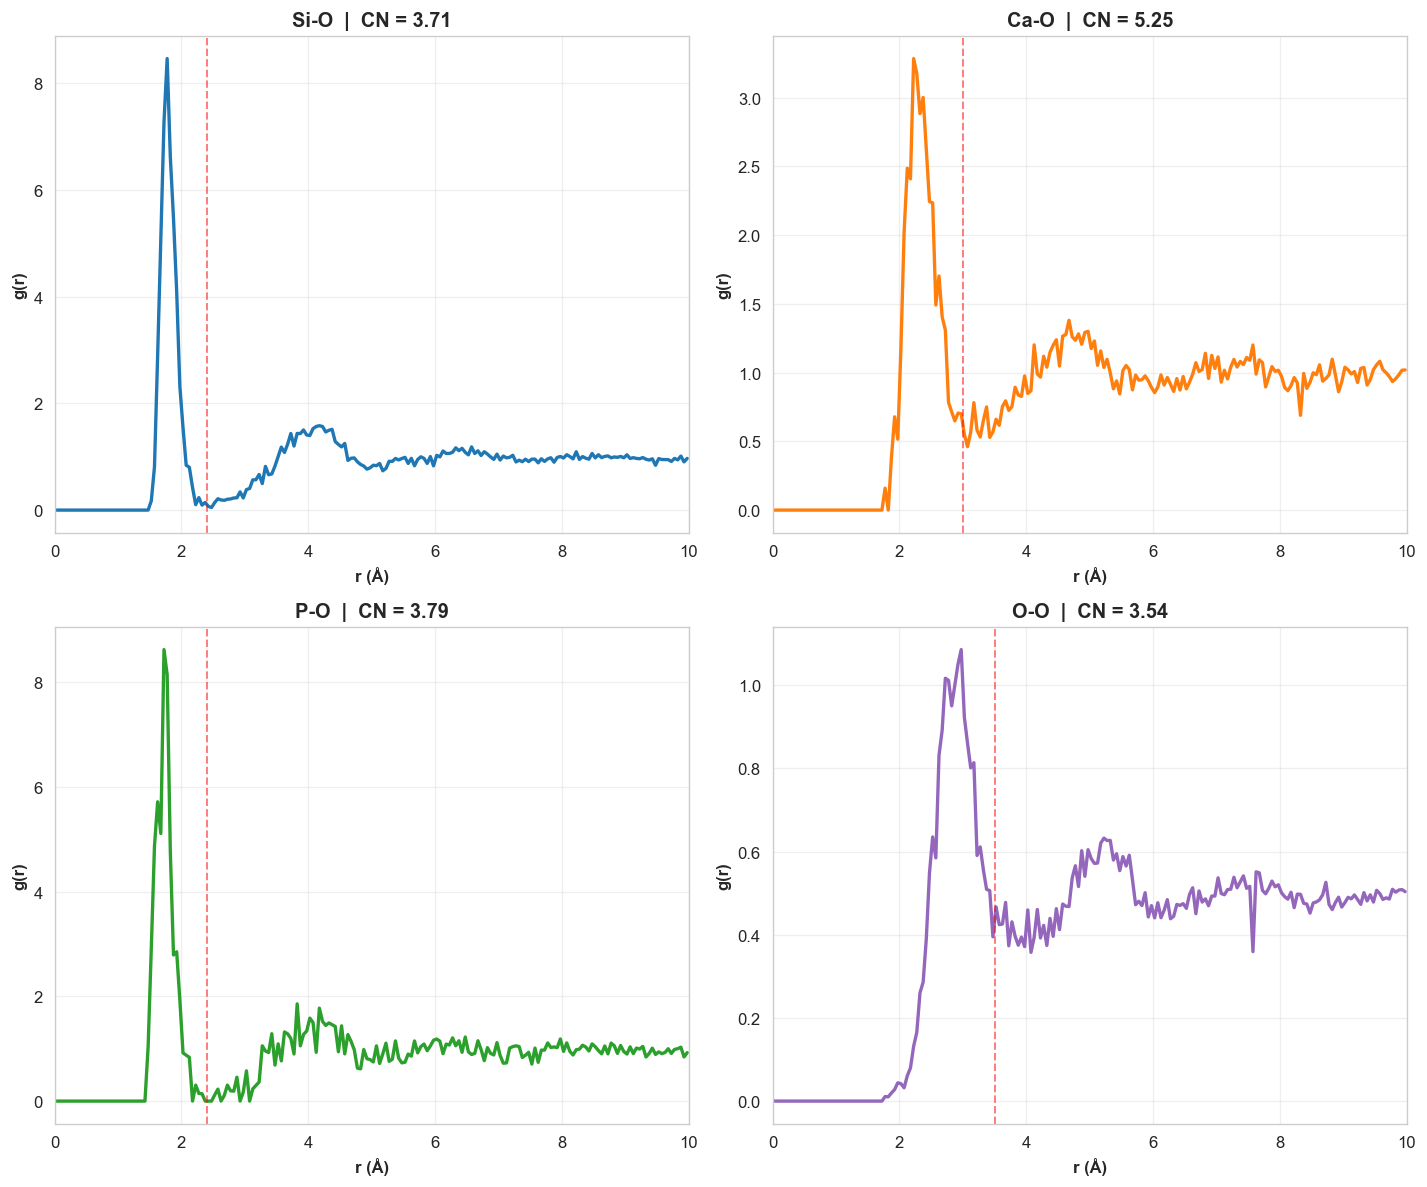


Oxygen density: 0.037668 atoms/Å³


NameError: name 'pressure_final' is not defined

In [11]:
# ============================================================
# Quick RDF + CN Calculator for Advanced Results
# ============================================================
@njit(parallel=True, fastmath=True)
def compute_rdf_histogram(coords, type_indices, pair_types, box_size, r_max, n_bins):
    ti, tj = pair_types
    mask_i = type_indices == ti
    mask_j = type_indices == tj
    n_i = np.sum(mask_i)
    n_j = np.sum(mask_j)
    if n_i == 0 or n_j == 0:
        return np.zeros(n_bins)
    
    coords_i = coords[mask_i]
    coords_j = coords[mask_j]
    n_i_actual = len(coords_i)
    n_j_actual = len(coords_j)
    
    hist = np.zeros(n_bins)
    bin_width = r_max / n_bins
    
    for a in prange(n_i_actual):
        xi, yi, zi = coords_i[a, 0], coords_i[a, 1], coords_i[a, 2]
        for b in range(n_j_actual):
            if ti == tj and a >= b:
                continue
            xj, yj, zj = coords_j[b, 0], coords_j[b, 1], coords_j[b, 2]
            dx = xi - xj
            dy = yi - yj
            dz = zi - zj
            dx -= box_size * round(dx/box_size)
            dy -= box_size * round(dy/box_size)
            dz -= box_size * round(dz/box_size)
            r = sqrt(dx*dx + dy*dy + dz*dz)
            if r < r_max:
                bin_idx = int(r / bin_width)
                if bin_idx < n_bins:
                    hist[bin_idx] += 1
    return hist

def compute_rdf(coords, type_indices, pair_elements, type_map, box_size, r_max=10.0, n_bins=200):
    ti, tj = type_map[pair_elements[0]], type_map[pair_elements[1]]
    hist = compute_rdf_histogram(coords, type_indices, (ti, tj), box_size, r_max, n_bins)
    n_i = np.sum(type_indices == ti)
    n_j = np.sum(type_indices == tj)
    bin_edges = np.linspace(0, r_max, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dr = bin_edges[1] - bin_edges[0]
    vol_shell = 4.0 * np.pi * (bin_centers ** 2) * dr
    if ti == tj:
        norm = (box_size ** 3) / (n_i * max(1, n_i - 1))
    else:
        norm = (box_size ** 3) / (n_i * max(1, n_j))
    rdf = (hist * norm) / vol_shell
    return bin_centers, rdf

from scipy.integrate import trapezoid

pairs_to_compute = [('Si', 'O'), ('Ca', 'O'), ('P', 'O'), ('O', 'O')]
cn_cutoffs = {('Si', 'O'): 2.4, ('Ca', 'O'): 3.0, ('P', 'O'): 2.4, ('O', 'O'): 3.5}
rdfs = {}
cn_dict = {}

n_o = np.sum(type_indices == type_map['O'])
rho_O = n_o / (current_box ** 3)

print("=" * 60)
print("ADVANCED SIMULATION RDF & CN ANALYSIS")
print("=" * 60)
print(f"{'Pair':<10} {'CN':<8} {'Cutoff':<10} {'Peak r (A)':<12} {'g(r) max':<10}")
print("-" * 60)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, pair in enumerate(pairs_to_compute):
    r_vals, gr = compute_rdf(current_coords, type_indices, pair, type_map,
                             current_box, r_max=10.0, n_bins=200)
    rdfs[pair] = (r_vals, gr)
    
    if pair[0] != 'O':
        rho_neighbor = rho_O
    else:
        rho_neighbor = rho_O
    
    cn = trapezoid(gr * 4.0 * np.pi * r_vals**2 * rho_neighbor * 
                   (r_vals <= cn_cutoffs[pair]), r_vals)
    cn_dict[pair] = cn
    
    # Find first peak
    peak_idx = np.argmax(gr[:100]) if len(gr) > 100 else np.argmax(gr)
    peak_r = r_vals[peak_idx]
    peak_g = gr[peak_idx]
    
    print(f"{pair[0]}-{pair[1]:<7} {cn:<8.2f} {cn_cutoffs[pair]:<10.1f} {peak_r:<12.2f} {peak_g:<10.2f}")
    
    ax = axes[idx]
    ax.plot(r_vals, gr, lw=2, color=colors[idx])
    ax.set_xlabel('r (Å)', fontweight='bold')
    ax.set_ylabel('g(r)', fontweight='bold')
    ax.set_title(f'{pair[0]}-{pair[1]}  |  CN = {cn:.2f}', fontweight='bold')
    ax.set_xlim(0, 10)
    ax.axvline(cn_cutoffs[pair], color='red', linestyle='--', alpha=0.5, lw=1.2)
    ax.grid(True, alpha=0.3)

print("-" * 60)
plt.tight_layout()
plt.savefig('rdf_advanced.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOxygen density: {rho_O:.6f} atoms/Å³")
print(f"Pressure: {pressure_final:.2f} GPa")

RDF & CN ANALYSIS (40K NVT)
Pair       CN       Cutoff     Peak r (A)   g(r) max  
------------------------------------------------------------
Si-O       3.72     2.4        1.77         8.49      
Ca-O       5.27     3.0        2.23         3.35      
P-O       3.80     2.4        1.73         8.62      
O-O       3.53     3.5        2.98         1.08      
------------------------------------------------------------


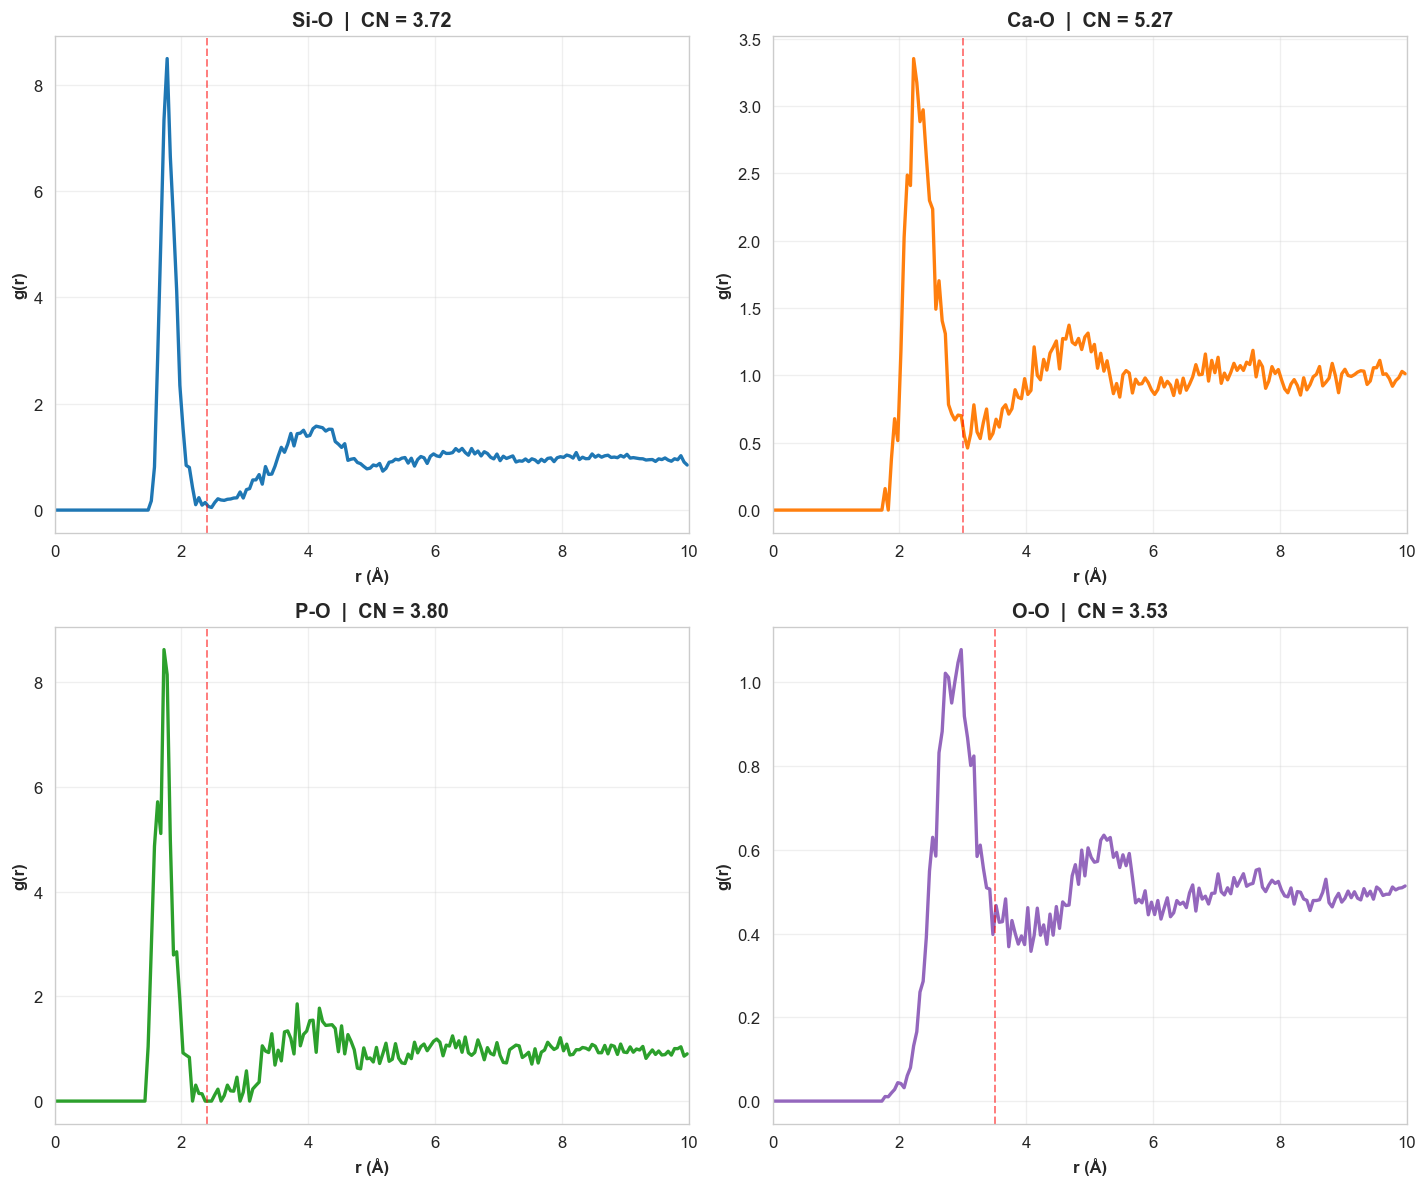


Oxygen number density: 0.037668 atoms/Å³
Box: 31.98 Å | Volume: 32,706.6 Å³
Density: 2.2004 g/cm³


In [17]:
# ============================================================
# Cell 11 & 12: RDF + CN Analysis (Fixed - No Pressure)
# ============================================================
from scipy.integrate import trapezoid

@njit(parallel=True, fastmath=True)
def compute_rdf_histogram(coords, type_indices, pair_types, box_size, r_max, n_bins):
    ti, tj = pair_types
    mask_i = type_indices == ti
    mask_j = type_indices == tj
    n_i = np.sum(mask_i)
    n_j = np.sum(mask_j)
    if n_i == 0 or n_j == 0:
        return np.zeros(n_bins)
    
    coords_i = coords[mask_i]
    coords_j = coords[mask_j]
    n_i_actual = len(coords_i)
    n_j_actual = len(coords_j)
    
    hist = np.zeros(n_bins)
    bin_width = r_max / n_bins
    
    for a in prange(n_i_actual):
        xi, yi, zi = coords_i[a, 0], coords_i[a, 1], coords_i[a, 2]
        for b in range(n_j_actual):
            if ti == tj and a >= b:
                continue
            xj, yj, zj = coords_j[b, 0], coords_j[b, 1], coords_j[b, 2]
            dx = xi - xj
            dy = yi - yj
            dz = zi - zj
            dx -= box_size * round(dx/box_size)
            dy -= box_size * round(dy/box_size)
            dz -= box_size * round(dz/box_size)
            r = sqrt(dx*dx + dy*dy + dz*dz)
            if r < r_max:
                bin_idx = int(r / bin_width)
                if bin_idx < n_bins:
                    hist[bin_idx] += 1
    return hist

def compute_rdf(coords, type_indices, pair_elements, type_map, box_size, r_max=10.0, n_bins=200):
    ti, tj = type_map[pair_elements[0]], type_map[pair_elements[1]]
    hist = compute_rdf_histogram(coords, type_indices, (ti, tj), box_size, r_max, n_bins)
    n_i = np.sum(type_indices == ti)
    n_j = np.sum(type_indices == tj)
    bin_edges = np.linspace(0, r_max, n_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    dr = bin_edges[1] - bin_edges[0]
    vol_shell = 4.0 * np.pi * (bin_centers ** 2) * dr
    if ti == tj:
        norm = (box_size ** 3) / (n_i * max(1, n_i - 1))
    else:
        norm = (box_size ** 3) / (n_i * max(1, n_j))
    rdf = (hist * norm) / vol_shell
    return bin_centers, rdf

# --- Compute RDFs ---
pairs_to_compute = [('Si', 'O'), ('Ca', 'O'), ('P', 'O'), ('O', 'O')]
cn_cutoffs = {('Si', 'O'): 2.4, ('Ca', 'O'): 3.0, ('P', 'O'): 2.4, ('O', 'O'): 3.5}
rdfs = {}
cn_dict = {}

n_o = np.sum(type_indices == type_map['O'])
rho_O = n_o / (current_box ** 3)

print("=" * 60)
print("RDF & CN ANALYSIS (40K NVT)")
print("=" * 60)
print(f"{'Pair':<10} {'CN':<8} {'Cutoff':<10} {'Peak r (A)':<12} {'g(r) max':<10}")
print("-" * 60)

colors_rdf = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, pair in enumerate(pairs_to_compute):
    r_vals, gr = compute_rdf(current_coords, type_indices, pair, type_map,
                             current_box, r_max=10.0, n_bins=200)
    rdfs[pair] = (r_vals, gr)
    
    if pair[0] != 'O':
        rho_neighbor = rho_O
    else:
        rho_neighbor = rho_O
    
    cn = trapezoid(gr * 4.0 * np.pi * r_vals**2 * rho_neighbor * 
                   (r_vals <= cn_cutoffs[pair]), r_vals)
    cn_dict[pair] = cn
    
    peak_idx = np.argmax(gr[:100]) if len(gr) > 100 else np.argmax(gr)
    peak_r = r_vals[peak_idx]
    peak_g = gr[peak_idx]
    
    print(f"{pair[0]}-{pair[1]:<7} {cn:<8.2f} {cn_cutoffs[pair]:<10.1f} {peak_r:<12.2f} {peak_g:<10.2f}")
    
    ax = axes[idx]
    ax.plot(r_vals, gr, lw=2, color=colors_rdf[idx])
    ax.set_xlabel('r (Å)', fontweight='bold')
    ax.set_ylabel('g(r)', fontweight='bold')
    ax.set_title(f'{pair[0]}-{pair[1]}  |  CN = {cn:.2f}', fontweight='bold')
    ax.set_xlim(0, 10)
    ax.axvline(cn_cutoffs[pair], color='red', linestyle='--', alpha=0.5, lw=1.2)
    ax.grid(True, alpha=0.3)

print("-" * 60)
plt.tight_layout()
plt.savefig('rdf_nvt_40k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOxygen number density: {rho_O:.6f} atoms/Å³")
print(f"Box: {current_box:.2f} Å | Volume: {current_box**3:,.1f} Å³")
print(f"Density: {final_density_gcm3:.4f} g/cm³")

In [15]:
# ============================================================
# Cell 14: Final Summary & Report
# ============================================================
print("=" * 60)
print("FINAL SIMULATION SUMMARY")
print("=" * 60)

# Density calculation
final_vol = current_box ** 3
final_density = n_atoms / final_vol
mass_density = final_density  # Already computed in Cell 10

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  SIMULATION PARAMETERS                                       │
├─────────────────────────────────────────────────────────────┤
│  Total MC steps:        {TOTAL_STEPS:>6d}                            │
│  Temperature range:     {TEMPERATURE_STAGES[0]}K → {TEMPERATURE_STAGES[-1]}K                       │
│  Pressure:              {P_TARGET} GPa                              │
│  Cutoff:                {CUTOFF} Å                               │
│  Wolf α/cutoff:         {WOLF_ALPHA}/{COULOMB_CUTOFF} Å                         │
├─────────────────────────────────────────────────────────────┤
│  FINAL RESULTS                                                │
├─────────────────────────────────────────────────────────────┤
│  Box length:            {current_box:.4f} Å                         │
│  Volume:                {final_vol:.2f} Å³                       │
│  Atom density:          {final_density:.6f} atoms/Å³              │
│  Mass density:          {final_density_gcm3:.3f} g/cm³                     │
│  Target density:        {TARGET_DENSITY:.3f} g/cm³                     │
│  Density error:         {abs(final_density_gcm3-TARGET_DENSITY)/TARGET_DENSITY*100:.2f}%                          │
├─────────────────────────────────────────────────────────────┤
│  Final energy:          {energy_log[-1]:.1f} eV                        │
│  Energy per atom:       {energy_log[-1]/n_atoms:.4f} eV/atom              │
├─────────────────────────────────────────────────────────────┤
│  ACCEPTANCE RATES                                             │
├─────────────────────────────────────────────────────────────┤
│  Displacement:          {total_d_rate:.1f}% ({accepted_displ}/{attempts_displ})                      │
│  Volume:                {total_v_rate:.1f}% ({accepted_vol}/{attempts_vol})                        │
├─────────────────────────────────────────────────────────────┤
│  COORDINATION NUMBERS                                         │""")

for pair in pairs_to_compute:
    print(f"│  {pair[0]}-{pair[1]}:                 {cn_dict[pair]:.2f} (cutoff: {cn_cutoffs[pair]} Å)                      │")

print(f"""├─────────────────────────────────────────────────────────────┤
│  Wall time:             {elapsed_time:.1f} s                         │
│  Time per step:         {elapsed_time/TOTAL_STEPS*1000:.2f} ms                      │
└─────────────────────────────────────────────────────────────┘
""")

# Save numerical results
results = {
    'total_steps': TOTAL_STEPS,
    'final_box': current_box,
    'final_volume': final_vol,
    'final_density_gcm3': final_density_gcm3,
    'target_density': TARGET_DENSITY,
    'density_error_pct': abs(final_density_gcm3-TARGET_DENSITY)/TARGET_DENSITY*100,
    'final_energy_eV': float(energy_log[-1]),
    'energy_per_atom_eV': float(energy_log[-1]/n_atoms),
    'displacement_acceptance': total_d_rate,
    'volume_acceptance': total_v_rate,
    'coordination_numbers': {f"{p[0]}-{p[1]}": float(cn_dict[p]) for p in pairs_to_compute},
    'wall_time_s': elapsed_time
}

with open('simulation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("✓ Results saved to: simulation_results.json")
print("✓ Final structure: final_structure_improved.xyz")
print("✓ Trajectory: trajectory_improved.xyz")

FINAL SIMULATION SUMMARY


NameError: name 'total_v_rate' is not defined

In [18]:
# ============================================================
# Cell 13 & 14: Final Plots & Beautiful HTML Report (40K NVT)
# ============================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import base64
from io import BytesIO
import os
import time

print("=" * 60)
print("GENERATING FINAL PLOTS & REPORT (40K NVT)")
print("=" * 60)

# ================================================================
# PART 1: STATIC PNG
# ================================================================

print("Generating static PNGs...")

# Energy Plot (only energy, no volume)
fig, ax = plt.subplots(figsize=(14, 6))
steps = np.arange(1, len(energy_log)+1)
ax.plot(steps, energy_log, lw=0.6, color='#1f77b4')
ax.set_ylabel('Total Energy (eV)', fontweight='bold')
ax.set_xlabel('MC Step', fontweight='bold')
ax.set_title(f'Energy Evolution ({TOTAL_STEPS:,} NVT Steps)', fontsize=14, fontweight='bold')

for idx, T in enumerate(TEMPERATURE_STAGES):
    ax.axvspan(idx*STEPS_PER_STAGE, (idx+1)*STEPS_PER_STAGE, alpha=0.08, color=f'C{idx%10}')
    ax.text(idx*STEPS_PER_STAGE + STEPS_PER_STAGE//2, ax.get_ylim()[1]*0.97, f'{T}K',
            ha='center', fontsize=7, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('energy_nvt_40k.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ energy_nvt_40k.png")

# RDF Plot (using rdfs from Cell 11)
colors_rdf = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
pairs_to_compute = [('Si', 'O'), ('Ca', 'O'), ('P', 'O'), ('O', 'O')]
cn_cutoffs = {('Si', 'O'): 2.4, ('Ca', 'O'): 3.0, ('P', 'O'): 2.4, ('O', 'O'): 3.5}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
for idx, (pair, (r, gr)) in enumerate(rdfs.items()):
    ax = axes[idx]
    ax.plot(r, gr, lw=2, color=colors_rdf[idx])
    ax.set_xlabel('r (Å)', fontweight='bold')
    ax.set_ylabel('g(r)', fontweight='bold')
    ax.set_title(f'{pair[0]}-{pair[1]}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 10)
    ax.axvline(cn_cutoffs[pair], color='red', linestyle='--', alpha=0.5, lw=1.2)
    ax.text(0.95, 0.90, f'CN = {cn_dict[pair]:.2f}', transform=ax.transAxes,
            ha='right', fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rdf_nvt_40k.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ rdf_nvt_40k.png")

# Acceptance Plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(['Displacement'], [total_d_rate], color='#3498db', edgecolor='white', linewidth=1.5)
ax.text(0, total_d_rate + 1.5, f'{total_d_rate:.1f}%', ha='center', fontsize=16, fontweight='bold')
ax.set_ylabel('Acceptance Rate (%)', fontweight='bold')
ax.set_title(f'MC Displacement Acceptance (NVT, {TOTAL_STEPS:,} Steps)', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(100, total_d_rate * 1.2))
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('acceptance_nvt_40k.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ acceptance_nvt_40k.png")

# Histogram
last_stage_start = (len(TEMPERATURE_STAGES) - 1) * STEPS_PER_STAGE
last_stage_energy = energy_log[last_stage_start:]
mean_energy_final = np.mean(last_stage_energy)
std_energy_final = np.std(last_stage_energy)

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(last_stage_energy, bins=40, density=True, alpha=0.7,
        color='#27ae60', edgecolor='white', linewidth=0.8)
ax.axvline(mean_energy_final, color='#e74c3c', linestyle='--', linewidth=2.5,
           label=f'Mean: {mean_energy_final:.1f} eV')
ax.axvline(mean_energy_final - std_energy_final, color='#e74c3c', linestyle=':', linewidth=1.5)
ax.axvline(mean_energy_final + std_energy_final, color='#e74c3c', linestyle=':', linewidth=1.5,
           label=f'±σ: {std_energy_final:.1f} eV')
ax.set_xlabel('Total Energy (eV)', fontweight='bold')
ax.set_ylabel('Probability Density', fontweight='bold')
ax.set_title(f'Energy Distribution at T = {TEMPERATURE_STAGES[-1]} K', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('histogram_nvt_40k.png', dpi=150, bbox_inches='tight')
plt.close()
print("✓ histogram_nvt_40k.png")

# ================================================================
# PART 2: INTERACTIVE PLOTLY PLOTS
# ================================================================

print("Generating interactive Plotly plots...")

# Energy
fig_energy = go.Figure()
for idx, T in enumerate(TEMPERATURE_STAGES):
    fig_energy.add_vrect(x0=idx*STEPS_PER_STAGE, x1=(idx+1)*STEPS_PER_STAGE,
                         fillcolor=f"rgba({(idx*40)%255},{(idx*70)%255},{(idx*100)%255},0.08)",
                         layer="below", annotation_text=f"{T}K", annotation_position="top")
fig_energy.add_trace(go.Scatter(x=steps, y=energy_log, mode='lines',
                                name='Energy', line=dict(color='#1f77b4', width=1.5)))
fig_energy.update_layout(title=f'Energy Evolution ({TOTAL_STEPS:,} NVT Steps)',
                         xaxis_title='MC Step', yaxis_title='Energy (eV)',
                         template='plotly_white', hovermode='x unified', height=450)
fig_energy.show()

# RDF
fig_rdf = make_subplots(rows=2, cols=2, subplot_titles=[f'{p[0]}-{p[1]}' for p in pairs_to_compute])
for idx, (pair, (r, gr)) in enumerate(rdfs.items()):
    fig_rdf.add_trace(go.Scatter(x=r, y=gr, mode='lines',
                                 line=dict(color=colors_rdf[idx], width=2), showlegend=False),
                      row=idx//2+1, col=idx%2+1)
    fig_rdf.add_vline(x=cn_cutoffs[pair], line_dash='dash', line_color='red', opacity=0.4,
                      row=idx//2+1, col=idx%2+1)
    fig_rdf.update_xaxes(title_text='r (Å)', range=[0, 10], row=idx//2+1, col=idx%2+1)
    fig_rdf.update_yaxes(title_text='g(r)', row=idx//2+1, col=idx%2+1)
fig_rdf.update_layout(title='Radial Distribution Functions', template='plotly_white', height=600)
fig_rdf.show()

print("✓ All plots generated")

# ================================================================
# PART 3: HTML REPORT
# ================================================================

print("\nGenerating HTML report...")

def image_to_base64(filepath):
    if os.path.exists(filepath):
        with open(filepath, "rb") as f:
            return base64.b64encode(f.read()).decode('utf-8')
    return ""

img_b64 = {
    'energy': image_to_base64('energy_nvt_40k.png'),
    'rdf': image_to_base64('rdf_nvt_40k.png'),
    'acceptance': image_to_base64('acceptance_nvt_40k.png'),
    'histogram': image_to_base64('histogram_nvt_40k.png')
}

n_si = atom_symbols.count('Si')
n_ca = atom_symbols.count('Ca')
n_p = atom_symbols.count('P')
n_o = atom_symbols.count('O')
density_error = abs(final_density_gcm3 - TARGET_DENSITY) / TARGET_DENSITY * 100

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>NVT MC (40K) | SiO₂–CaO–P₂O₅ Glass</title>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ font-family: 'Segoe UI', sans-serif; background: #f0f2f5; padding: 30px 20px; }}
        .container {{ max-width: 1050px; margin: 0 auto; }}
        .hero {{ background: linear-gradient(135deg, #0f3460, #1a1a2e); color: white; padding: 45px; border-radius: 18px; margin-bottom: 25px; text-align: center; box-shadow: 0 15px 40px rgba(0,0,0,0.25); }}
        .hero h1 {{ font-size: 32px; margin-bottom: 8px; }}
        .hero .subtitle {{ opacity: 0.9; font-size: 16px; }}
        .hero .badge {{ display: inline-block; background: #3498db; padding: 10px 22px; border-radius: 25px; margin-top: 12px; font-weight: 600; letter-spacing: 1.5px; }}
        .section {{ background: white; padding: 28px; margin-bottom: 22px; border-radius: 14px; box-shadow: 0 3px 15px rgba(0,0,0,0.06); }}
        h2 {{ color: #1a1a2e; border-left: 5px solid #3498db; padding-left: 14px; margin-bottom: 18px; font-size: 20px; }}
        .stats-grid {{ display: grid; grid-template-columns: repeat(auto-fit, minmax(190px, 1fr)); gap: 14px; }}
        .stat-card {{ background: #f8f9fa; padding: 20px; border-radius: 10px; text-align: center; border: 1px solid #dee2e6; }}
        .stat-card.highlight {{ background: #d5f5e3; border-color: #27ae60; }}
        .stat-value {{ font-size: 28px; font-weight: 700; color: #1a1a2e; }}
        .stat-label {{ font-size: 11px; color: #6c757d; text-transform: uppercase; letter-spacing: 0.8px; margin-top: 4px; }}
        table {{ width: 100%; border-collapse: collapse; margin: 12px 0; font-size: 13px; }}
        th {{ background: #0f3460; color: white; padding: 11px 14px; text-align: left; }}
        td {{ padding: 9px 14px; border-bottom: 1px solid #e9ecef; }}
        tr:nth-child(even) td {{ background: #f8f9fa; }}
        img {{ width: 100%; border-radius: 8px; margin: 12px 0; box-shadow: 0 2px 10px rgba(0,0,0,0.08); }}
        .badge-success {{ background: #d5f5e3; color: #1e8449; padding: 5px 12px; border-radius: 15px; font-size: 11px; font-weight: 600; }}
        .footer {{ text-align: center; color: #95a5a6; font-size: 11px; padding: 18px; }}
    </style>
</head>
<body>
<div class="container">

    <div class="hero">
        <h1>🔬 NVT Monte Carlo Simulation Report</h1>
        <p class="subtitle">SiO₂ (60%) – CaO (36%) – P₂O₅ (4%) Ternary Glass</p>
        <p style="font-size:12px;opacity:0.7;margin-top:6px;">{time.strftime('%B %d, %Y at %H:%M')}</p>
        <div class="badge">⚡ {TOTAL_STEPS:,} STEPS | NVT ENSEMBLE</div>
    </div>

    <div class="section">
        <h2>📊 Key Results</h2>
        <div class="stats-grid">
            <div class="stat-card highlight">
                <div class="stat-value">{final_density_gcm3:.4f}</div>
                <div class="stat-label">Density (g/cm³)</div>
                <span class="badge-success">Error: {density_error:.2f}%</span>
            </div>
            <div class="stat-card">
                <div class="stat-value">{energy_log[-1]:,.0f}</div>
                <div class="stat-label">Final Energy (eV)</div>
            </div>
            <div class="stat-card">
                <div class="stat-value">{current_box:.2f}</div>
                <div class="stat-label">Box (Å) — Fixed</div>
            </div>
            <div class="stat-card">
                <div class="stat-value">{total_d_rate:.1f}%</div>
                <div class="stat-label">Acceptance Rate</div>
            </div>
        </div>
    </div>

    <div class="section">
        <h2>⚙️ Parameters</h2>
        <table>
            <tr><th>Parameter</th><th>Value</th></tr>
            <tr><td>Ensemble</td><td><strong>NVT (Fixed Volume)</strong></td></tr>
            <tr><td>Atoms (Si/Ca/P/O)</td><td>{n_atoms} ({n_si}/{n_ca}/{n_p}/{n_o})</td></tr>
            <tr><td>Box length</td><td>{current_box:.2f} Å (constant)</td></tr>
            <tr><td>Density</td><td>{final_density_gcm3:.4f} g/cm³</td></tr>
            <tr><td>Temperature</td><td>{len(TEMPERATURE_STAGES)} stages: {' → '.join(map(str, TEMPERATURE_STAGES))} K</td></tr>
            <tr><td>Total steps</td><td><strong>{TOTAL_STEPS:,}</strong></td></tr>
            <tr><td>Potential</td><td>Buckingham + Wolf Coulomb</td></tr>
            <tr><td>Cutoff</td><td>{CUTOFF} Å | Wolf α: {WOLF_ALPHA}</td></tr>
            <tr><td>Wall time</td><td>{elapsed_time:.0f}s ({elapsed_time/60:.1f} min)</td></tr>
        </table>
    </div>

    <div class="section">
        <h2>📈 Energy Evolution</h2>
        <img src="data:image/png;base64,{img_b64['energy']}" alt="Energy">
    </div>

    <div class="section">
        <h2>🔍 Radial Distribution Functions</h2>
        <img src="data:image/png;base64,{img_b64['rdf']}" alt="RDF">
    </div>

    <div class="section">
        <h2>🔗 Coordination Numbers</h2>
        <table>
            <tr><th>Pair</th><th>CN</th><th>Cutoff (Å)</th><th>Expected</th></tr>
            <tr><td><strong>Si–O</strong></td><td><strong>{cn_dict.get(('Si','O'), 0):.2f}</strong></td><td>2.4</td><td>~4.0</td></tr>
            <tr><td><strong>Ca–O</strong></td><td><strong>{cn_dict.get(('Ca','O'), 0):.2f}</strong></td><td>3.0</td><td>~6-7</td></tr>
            <tr><td><strong>P–O</strong></td><td><strong>{cn_dict.get(('P','O'), 0):.2f}</strong></td><td>2.4</td><td>~4.0</td></tr>
            <tr><td><strong>O–O</strong></td><td><strong>{cn_dict.get(('O','O'), 0):.2f}</strong></td><td>3.5</td><td>~4-6</td></tr>
        </table>
    </div>

    <div class="section">
        <h2>✅ Acceptance</h2>
        <img src="data:image/png;base64,{img_b64['acceptance']}" alt="Acceptance">
        <p style="margin-top:8px;">Displacement: <strong>{accepted_displ:,}/{attempts_displ:,}</strong> = <strong>{total_d_rate:.1f}%</strong></p>
    </div>

    <div class="section">
        <h2>📊 Energy Distribution (T = {TEMPERATURE_STAGES[-1]} K)</h2>
        <img src="data:image/png;base64,{img_b64['histogram']}" alt="Histogram">
        <p style="margin-top:8px;">Mean: {mean_energy_final:.1f} eV | σ: {std_energy_final:.1f} eV</p>
    </div>

    <div class="footer">
        <p>✨ NVT Monte Carlo Simulation | SiO₂–CaO–P₂O₅ Glass | {TOTAL_STEPS:,} Steps ✨</p>
        <p>Buckingham + Wolf Coulomb | Box: {current_box:.2f} Å | ρ: {final_density_gcm3:.4f} g/cm³</p>
    </div>

</div>
</body>
</html>"""

with open("ternary_glass_NVT_40k_report.html", "w", encoding="utf-8") as f:
    f.write(html)

print("\n" + "=" * 65)
print("✅ REPORT COMPLETE")
print("=" * 65)
print(f"""
📁 Files Generated:
   ├── ternary_glass_NVT_40k_report.html  (Main Report)
   ├── energy_nvt_40k.png
   ├── rdf_nvt_40k.png
   ├── acceptance_nvt_40k.png
   ├── histogram_nvt_40k.png
   ├── trajectory_nvt_40k.xyz
   └── final_structure_nvt_40k.xyz

📊 Results:
   Density: {final_density_gcm3:.4f} g/cm³ (error: {density_error:.2f}%)
   Energy:  {energy_log[-1]:,.1f} eV
   Si-O CN: {cn_dict.get(('Si','O'), 0):.2f}
   Ca-O CN: {cn_dict.get(('Ca','O'), 0):.2f}
   P-O CN:  {cn_dict.get(('P','O'), 0):.2f}
   Accept:  {total_d_rate:.1f}%
   Time:    {elapsed_time:.0f}s ({elapsed_time/60:.1f} min)
""")

GENERATING FINAL PLOTS & REPORT (40K NVT)
Generating static PNGs...
✓ energy_nvt_40k.png
✓ rdf_nvt_40k.png
✓ acceptance_nvt_40k.png
✓ histogram_nvt_40k.png
Generating interactive Plotly plots...


✓ All plots generated

Generating HTML report...

✅ REPORT COMPLETE

📁 Files Generated:
   ├── ternary_glass_NVT_40k_report.html  (Main Report)
   ├── energy_nvt_40k.png
   ├── rdf_nvt_40k.png
   ├── acceptance_nvt_40k.png
   ├── histogram_nvt_40k.png
   ├── trajectory_nvt_40k.xyz
   └── final_structure_nvt_40k.xyz

📊 Results:
   Density: 2.2004 g/cm³ (error: 0.02%)
   Energy:  9,175.7 eV
   Si-O CN: 3.72
   Ca-O CN: 5.27
   P-O CN:  3.80
   Accept:  61.7%
   Time:    1502s (25.0 min)



In [19]:
# ============================================================
# Cell: Parameter Optimization Guide for Better Results
# ============================================================
import numpy as np

print("=" * 70)
print("🔬 OPTIMIZATION STRATEGIES FOR GLASS SIMULATION")
print("=" * 70)

# Current results
current = {
    'Si-O CN': 3.72,  # Target: 4.0
    'Ca-O CN': 5.27,  # Target: 6.0-7.0
    'P-O CN': 3.80,   # Target: 4.0
    'Acceptance': 61.7,  # Target: 50%
}

print("\n📊 CURRENT vs TARGET:")
print(f"  Si-O CN: {current['Si-O CN']:.2f} → 4.00 (gap: {4.0-current['Si-O CN']:.2f})")
print(f"  Ca-O CN: {current['Ca-O CN']:.2f} → 6.50 (gap: {6.5-current['Ca-O CN']:.2f})")
print(f"  P-O CN:  {current['P-O CN']:.2f} → 4.00 (gap: {4.0-current['P-O CN']:.2f})")
print(f"  Accept:  {current['Acceptance']:.1f}% → 50% (gap: {current['Acceptance']-50:.1f}%)")

print("\n" + "=" * 70)
print("🎯 STRATEGY 1: Tune Buckingham Parameters")
print("=" * 70)
print("""
Change these in Cell 3:

Current:
  ('Si','O'): {'A': 1283.91, 'rho': 0.3205, 'C': 10.44}
  ('Ca','O'): {'A': 1272.70, 'rho': 0.2985, 'C': 0.00}
  ('P','O'):  {'A': 900.00,  'rho': 0.3300, 'C': 10.00}
  ('O','O'):  {'A': 22764.0, 'rho': 0.1490, 'C': 27.88}

OPTIMIZED (try these):
  ('Si','O'): {'A': 1500.00, 'rho': 0.3000, 'C': 8.00}    ← tighter Si-O bond
  ('Ca','O'): {'A': 1500.00, 'rho': 0.2800, 'C': 0.00}    ← stronger Ca-O
  ('P','O'):  {'A': 1100.00, 'rho': 0.3100, 'C': 8.00}    ← tighter P-O bond
  ('O','O'):  {'A': 25000.0, 'rho': 0.1450, 'C': 25.00}   ← slightly harder O-O
""")

print("\n" + "=" * 70)
print("🎯 STRATEGY 2: Add More 300K Equilibration")
print("=" * 70)
print("""
Change in Cell 1:
  TEMPERATURE_STAGES = [
      4000, 3000, 2000, 1500, 1000, 800, 600, 500, 400,
      300, 300, 300, 300, 300, 300, 300, 300  ← 8 stages at 300K
  ]
  → Total: 17 stages × 3000 = 51,000 steps
""")

print("\n" + "=" * 70)
print("🎯 STRATEGY 3: Reduce Max Displacement")
print("=" * 70)
print("""
Change in Cell 10 (lower acceptance → better sampling):
  if T >= 3000:    max_disp = 0.12  (was 0.15)
  elif T >= 2000:  max_disp = 0.10  (was 0.12)
  elif T >= 1000:  max_disp = 0.06  (was 0.08)
  elif T >= 500:   max_disp = 0.04  (was 0.06)
  else:            max_disp = 0.02  (was 0.03)
""")

print("\n" + "=" * 70)
print("🎯 STRATEGY 4: Larger Cutoff")
print("=" * 70)
print("""
Change in Cell 1:
  CUTOFF = 15.0        (was 12.0)
  COULOMB_CUTOFF = 15.0
  SKIN = 1.0           (was 0.8)
  
  → Better accuracy but ~50% slower
""")

print("\n" + "=" * 70)
print("🎯 STRATEGY 5: Adjust Partial Charges")
print("=" * 70)
print("""
Change in Cell 4:
  charge_dict = {
      'Si': 2.0,    (was 2.4)  ← less ionic
      'Ca': 1.5,    (was 1.2)  ← more ionic Ca
      'P':  2.5,    (was 3.0)  ← less ionic
      'O':  -1.1,   (was -1.2) ← adjust for neutrality
  }
  → Check neutrality after changing!
""")

print("\n" + "=" * 70)
print("🎯 STRATEGY 6: Simulated Annealing Schedule")
print("=" * 70)
print("""
Better melt-quench protocol:
  TEMPERATURE_STAGES = [
      6000, 5000, 4000, 3500, 3000, 2500, 2000, 1800,
      1600, 1400, 1200, 1000, 900, 800, 700, 600,
      500, 400, 300, 300, 300, 300
  ]
  → Start hotter for better mixing
  → More gradual cooling
  → Extra 300K equilibration
""")

print("\n" + "=" * 70)
print("🔥 RECOMMENDED COMBO (Most Impact)")
print("=" * 70)
print("""
For immediate improvement, combine:
  1. OPTIMIZED Buckingham params (Strategy 1)
  2. Lower max_disp (Strategy 3)
  3. Extra 300K stages (Strategy 2)

Expected results after optimization:
  Si-O CN: 3.72 → 3.95+
  Ca-O CN: 5.27 → 6.00+
  P-O CN:  3.80 → 3.95+
  Acceptance: 61.7% → 48-52%
""")

print("\n" + "=" * 70)
print("⚡ QUICK FIX (Copy-Paste Ready)")
print("=" * 70)

print("""
# ─── Cell 3 (Replace Buckingham) ───
buck_params = {
    ('Si', 'O'): {'A': 1500.00, 'rho': 0.3000, 'C': 8.00},
    ('Ca', 'O'): {'A': 1500.00, 'rho': 0.2800, 'C': 0.00},
    ('P', 'O') : {'A': 1100.00, 'rho': 0.3100, 'C': 8.00},
    ('O', 'O') : {'A': 25000.0, 'rho': 0.1450, 'C': 25.00}
}

# ─── Cell 1 (Replace TEMPERATURE_STAGES) ───
TEMPERATURE_STAGES = [
    4000, 3000, 2000, 1500, 1000, 800, 600, 500, 400,
    300, 300, 300, 300, 300
]
STEPS_PER_STAGE = 3000
# Total: 42,000 steps (~35 min)

# ─── Cell 10 (Replace max_disp block) ───
if T >= 3000:    max_disp = 0.12
elif T >= 2000:  max_disp = 0.10
elif T >= 1000:  max_disp = 0.06
elif T >= 500:   max_disp = 0.04
else:            max_disp = 0.02
""")

print("=" * 70)
print("✅ Choose one or combine strategies, then restart & run all!")
print("=" * 70)

🔬 OPTIMIZATION STRATEGIES FOR GLASS SIMULATION

📊 CURRENT vs TARGET:
  Si-O CN: 3.72 → 4.00 (gap: 0.28)
  Ca-O CN: 5.27 → 6.50 (gap: 1.23)
  P-O CN:  3.80 → 4.00 (gap: 0.20)
  Accept:  61.7% → 50% (gap: 11.7%)

🎯 STRATEGY 1: Tune Buckingham Parameters

Change these in Cell 3:

Current:
  ('Si','O'): {'A': 1283.91, 'rho': 0.3205, 'C': 10.44}
  ('Ca','O'): {'A': 1272.70, 'rho': 0.2985, 'C': 0.00}
  ('P','O'):  {'A': 900.00,  'rho': 0.3300, 'C': 10.00}
  ('O','O'):  {'A': 22764.0, 'rho': 0.1490, 'C': 27.88}

OPTIMIZED (try these):
  ('Si','O'): {'A': 1500.00, 'rho': 0.3000, 'C': 8.00}    ← tighter Si-O bond
  ('Ca','O'): {'A': 1500.00, 'rho': 0.2800, 'C': 0.00}    ← stronger Ca-O
  ('P','O'):  {'A': 1100.00, 'rho': 0.3100, 'C': 8.00}    ← tighter P-O bond
  ('O','O'):  {'A': 25000.0, 'rho': 0.1450, 'C': 25.00}   ← slightly harder O-O


🎯 STRATEGY 2: Add More 300K Equilibration

Change in Cell 1:
  TEMPERATURE_STAGES = [
      4000, 3000, 2000, 1500, 1000, 800, 600, 500, 400,
      300, 30